# Set up
**Import libraries**

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Load and merge datasets**

In [2]:

df = pd.read_csv("../data/bunny.csv")
habitat = pd.read_csv("../data/habitats.csv")

C:\Users\sanne\AppData\Local\Temp\ipykernel_2408\2618336038.py:1: DtypeWarning: Columns (0: Oryctolagus cuniculus) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/bunny.csv")


---

## 1. Business Understanding

**Business Objective** 

* The objective of this project is to develop a predictive model for observations of Oryctolagus cuniculus using environmental and temporal factors such as habitat type, seasonality, temperature, precipitation, and geographic location.
The model aims to predict where and when rabbit observations are most likely to occur, helping improve biodiversity monitoring, ecological research, and wildlife management decisions.

**Business Success Criteria**

* The model will be considered successful if it:
Achieves at least 75% prediction accuracy on unseen observation data
Correctly identifies seasonal and habitat-related patterns in rabbit observations
Maintains stable performance across different geographic regions and weather conditions

**Data Mining Goals**

* Develop a classification model that predicts the likelihood of observing Oryctolagus cuniculus using environmental variables such as habitat type, seasonality, temperature, precipitation, and geographic location.

**Data Mining Success Criteria**

* Our model should achieve at least:
75% accuracy in predicting observations of Oryctolagus cuniculus
70% precision when identifying locations and time periods with rabbit observations
75% recall in detecting actual rabbit observation occurrences based on habitat, seasonal, and weather-related variables
The model should also maintain stable predictive performance across different regions and seasons.

---

## 2. Data understanding / preparation
**Data exploration**


In [3]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,26.0,0,0
2,50.75,5.65,2010-01-03,3.0,0,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Oryctolagus cuniculus      object 
dtypes: float64(3), int64(1), object(1), str(1)
memory usage: 574.9+ MB


In [5]:
df.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,1.255879e+07,1.255879e+07,1.255878e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,8.136004e+00,2.212651e-01
std,6.647267e-01,8.779710e-01,6.264853e+01,2.511784e+00
min,3.500000e+00,3.350000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00
75%,5.280000e+01,6.200000e+00,6.000000e+00,0.000000e+00
max,5.350000e+01,5.340000e+01,1.000400e+05,1.637000e+03


**Check data distribution**

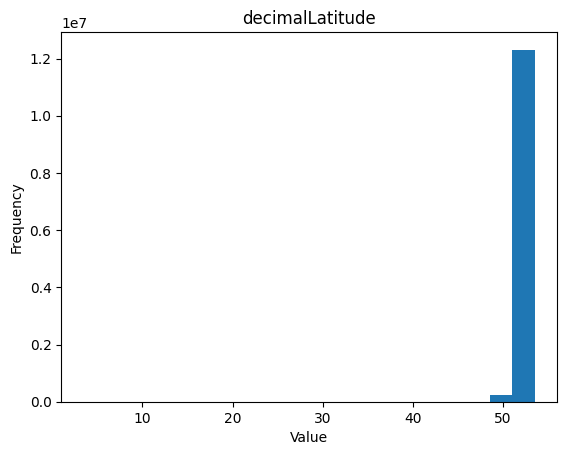

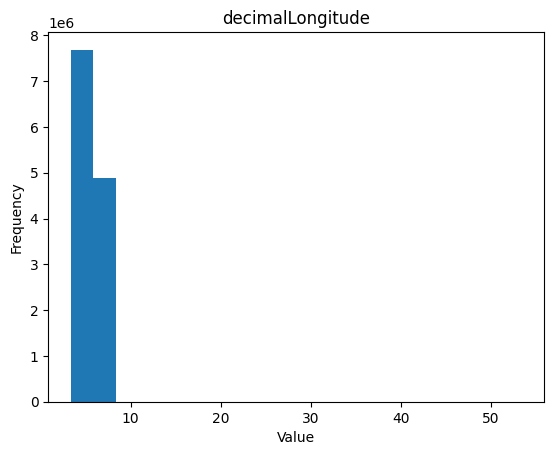

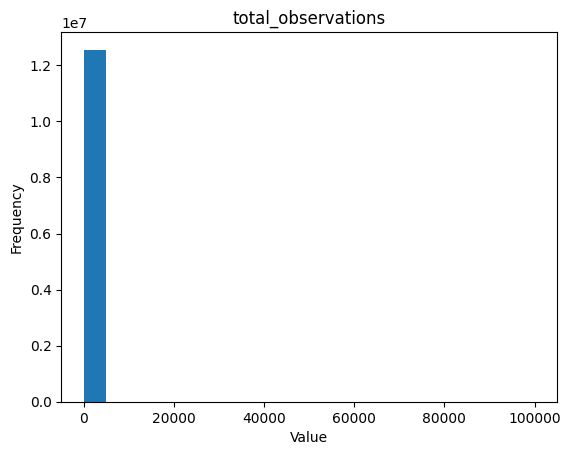

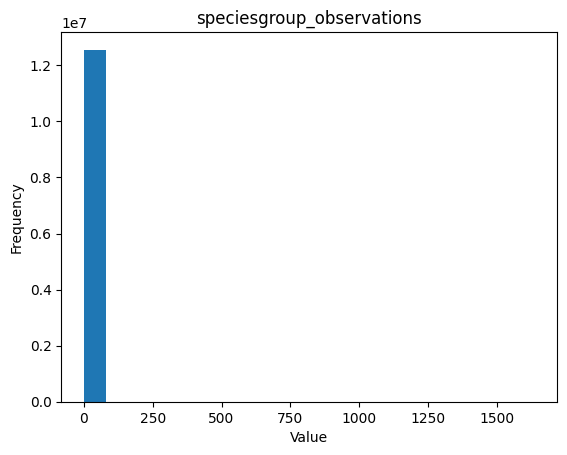

In [ ]:
for col in df.describe().columns:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

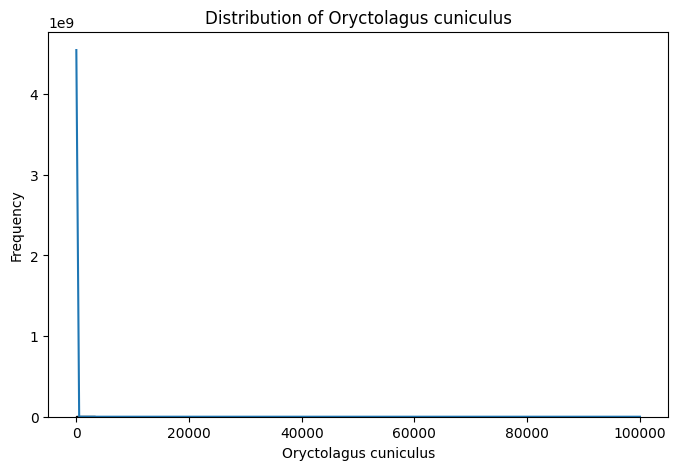

In [ ]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)
plt.figure(figsize=(8,5))
sns.histplot(df["total_observations"], bins=30, kde=True)

plt.title("Distribution of Oryctolagus cuniculus")
plt.xlabel("Oryctolagus cuniculus")
plt.ylabel("Frequency")

plt.show()

**Check duplicates, missing values or typos**

In [8]:
df.isnull().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           3
speciesgroup_observations    0
Oryctolagus cuniculus        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(habitat["main_habitat"].unique())

<StringArray>
['agricultural',        'built',        'other',        'water',
       'forest',        'coast', 'sand/heather',      'wetland',
         'dirt']
Length: 9, dtype: str


**Check if all bunnies are spot in the Netherlands**

In [11]:
in_nl = (
    df["decimalLatitude"].between(50.75, 53.55) &
    df["decimalLongitude"].between(3.35, 7.25)
)

print("All bunnies in Netherlands?", in_nl.all())
print("Bunnies outside Netherlands:", (~in_nl).sum())
df[~in_nl][["decimalLatitude", "decimalLongitude"]]

All bunnies in Netherlands? False
Bunnies outside Netherlands: 30


,decimalLatitude,decimalLongitude
12558756,3.55,53.40
12558757,3.65,53.40
12558758,3.75,53.40
12558759,3.50,53.30
12558760,3.50,53.20
12558761,3.50,53.10
12558762,3.60,53.10
12558763,3.70,53.10
12558764,3.80,53.10
12558765,3.50,53.00


### Findings
* The bunnies that are categorized as 'outside' the Netherlands have their latitude and longitude switched. We'll fix this to avoid issues with merging and mismatch habits.

In [ ]:
# Define NL box
in_nl = (
    df["decimalLatitude"].between(50.75, 53.55) &
    df["decimalLongitude"].between(3.35, 7.25)
)

# Swap lat/lon ONLY for incorrect rows
df.loc[~in_nl, ["decimalLatitude", "decimalLongitude"]] = (
    df.loc[~in_nl, ["decimalLongitude", "decimalLatitude"]].values
)

# Validate correction
in_nl_after = (
    df["decimalLatitude"].between(50.75, 53.55) &
    df["decimalLongitude"].between(3.35, 7.25)
)

print("All bunnies spot in Netherlands after fix?", in_nl_after.all())
print("Bunnies outside the Netherlands:", (~in_nl_after).sum())

All bunnies spot in Netherlands after fix? True
Still outside NL records: 0


**Merge datasets**

*We now merge the datasets because in our previous attempts we found missing values in the habitat data due to swapped latitude and longitude. We use a left join because we only want to add habitat information to the coordinates that match the spotted bunnies.*

In [13]:
# Merge habitats with bunny data with only matching decimalLatitude and decimalLongitude values
df = df.merge(habitat, how="left", on=["decimalLatitude", "decimalLongitude"])

**Check heatmap correlation**

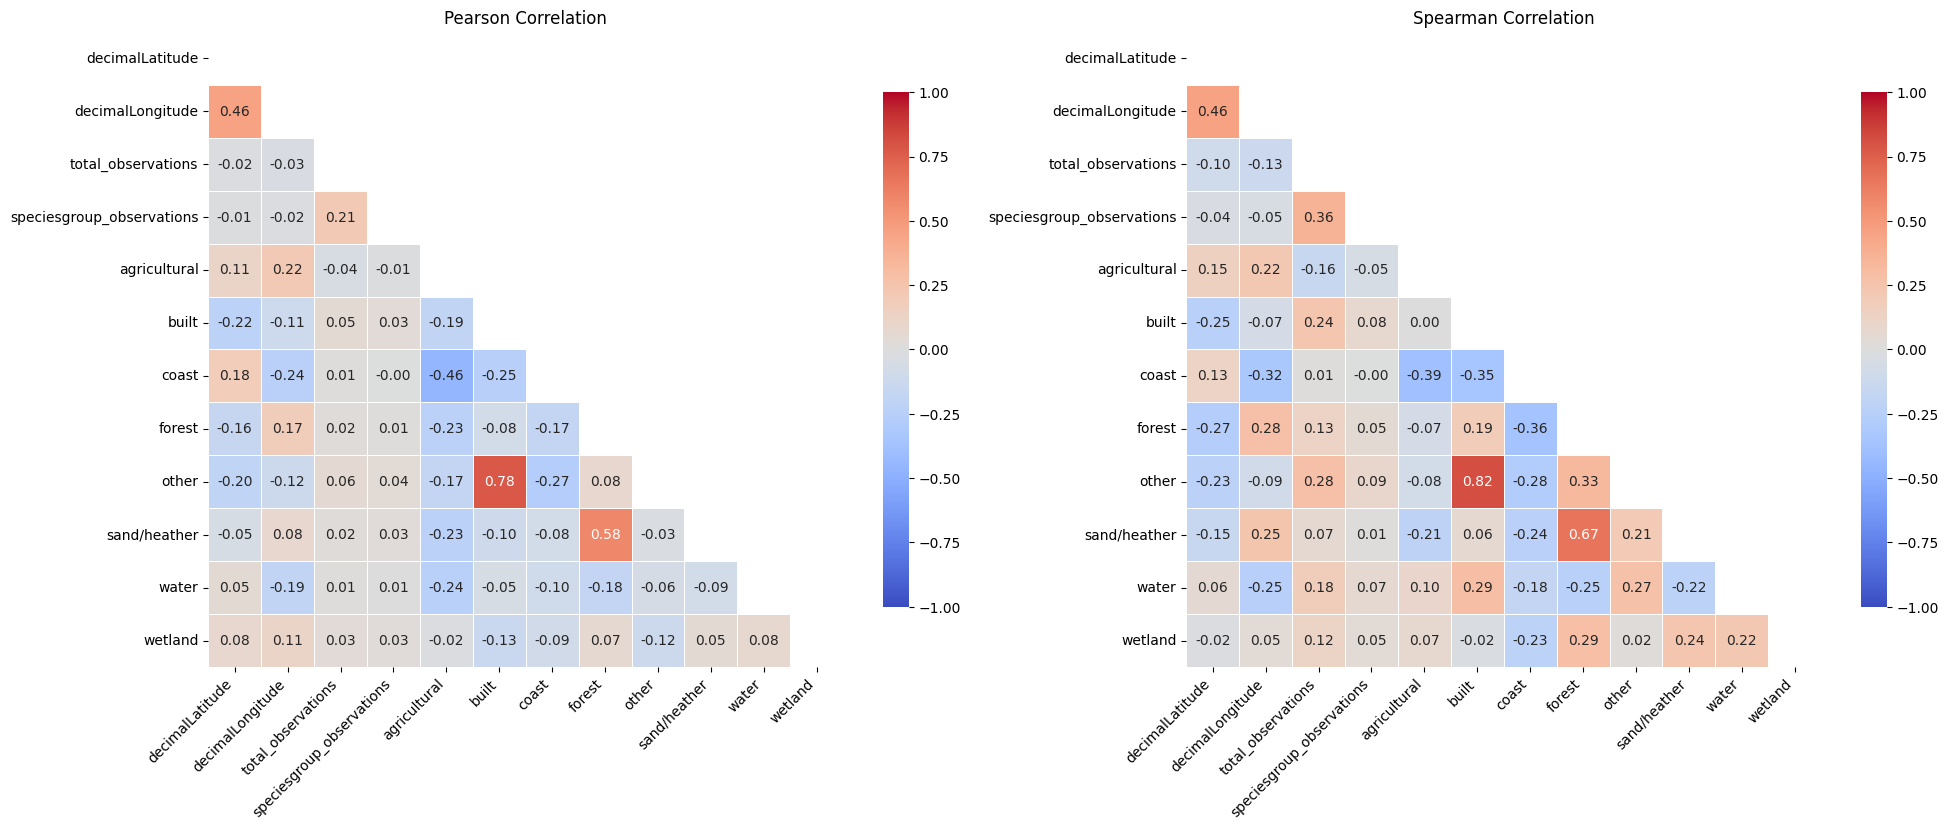

In [14]:
corr_pearson = df.corr(numeric_only=True, method="pearson")
corr_spearman = df.corr(numeric_only=True, method="spearman")

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Pearson
sns.heatmap(
    corr_pearson,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=axes[0]
)
axes[0].set_title("Pearson Correlation")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

# Spearman
sns.heatmap(
    corr_spearman,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=axes[1]
)
axes[1].set_title("Spearman Correlation")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Findings
* There is a moderate positive correlation between latitude and longitude (~0.45).
* Bunny observations (total and species group) show weak correlations with habitat types, meaning no strong habitat preference is directly visible from this analysis.
* Some habitat types are related to each other:
    * Built and ‘other’ are highly positively correlated (~0.78–0.82).
    * Forest and sand/heather show a strong positive relationship (~0.58–0.67).
    * Agricultural and coast show a negative correlation (~-0.39 to -0.46).
    * Coast and forest are negatively correlated (~-0.17 to -0.36).

In conclusion, bunnies do not strongly correlate with any specific habitat in this dataset.

In [17]:
print(df["main_habitat"].value_counts(dropna=False))

main_habitat
agricultural    9233520
coast           1098672
built            958416
forest           631152
water            543492
other             40908
sand/heather      29220
wetland           23376
dirt                 30
Name: count, dtype: int64


### Findings
* From the results above, we can conclude that most bunnies are found in agricultural areas. The second most common habitats are coastal and built environments.